In [4]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

# Sklearn tools
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('./reports', exist_ok=True)

import os
os.makedirs('../reports', exist_ok=True)

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [5]:
# Load processed data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

# Load best model and its name
best_model      = joblib.load('../models/best_model.pkl')
best_model_name = joblib.load('../models/best_model_name.pkl')
feature_names   = joblib.load('../models/feature_names.pkl')

print(f"Data loaded ✅")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\n🏆 Best Model: {best_model_name}")

# Quick check — current performance
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))
print(f"\nCurrent Performance:")
print(f"  Train Accuracy : {train_acc*100:.2f}%")
print(f"  Test  Accuracy : {test_acc*100:.2f}%")
print(f"  Gap            : {(train_acc - test_acc)*100:.2f}%")
print()
if train_acc - test_acc > 0.10:
    print("⚠️  Gap > 10% → Possible OVERFITTING detected!")
elif test_acc < 0.75:
    print("⚠️  Test accuracy < 75% → Possible UNDERFITTING!")
else:
    print("✅ Model looks well-fitted!")

Data loaded ✅
X_train : (800, 12)
X_test  : (154, 12)

🏆 Best Model: Decision Tree

Current Performance:
  Train Accuracy : 93.75%
  Test  Accuracy : 88.31%
  Gap            : 5.44%

✅ Model looks well-fitted!


Generating learning curves (this may take ~1 min)...

Model                         Train Acc    Val Acc      Gap
------------------------------------------------------------
  Logistic Regression             82.12%     82.00%    0.13%  ✅ Good
  Decision Tree                  100.00%     84.62%   15.37%  ⚠️ Overfit
  Decision Tree (Pruned)          93.47%     84.38%    9.09%  ✅ Good
  Random Forest                   93.47%     84.38%    9.09%  ✅ Good


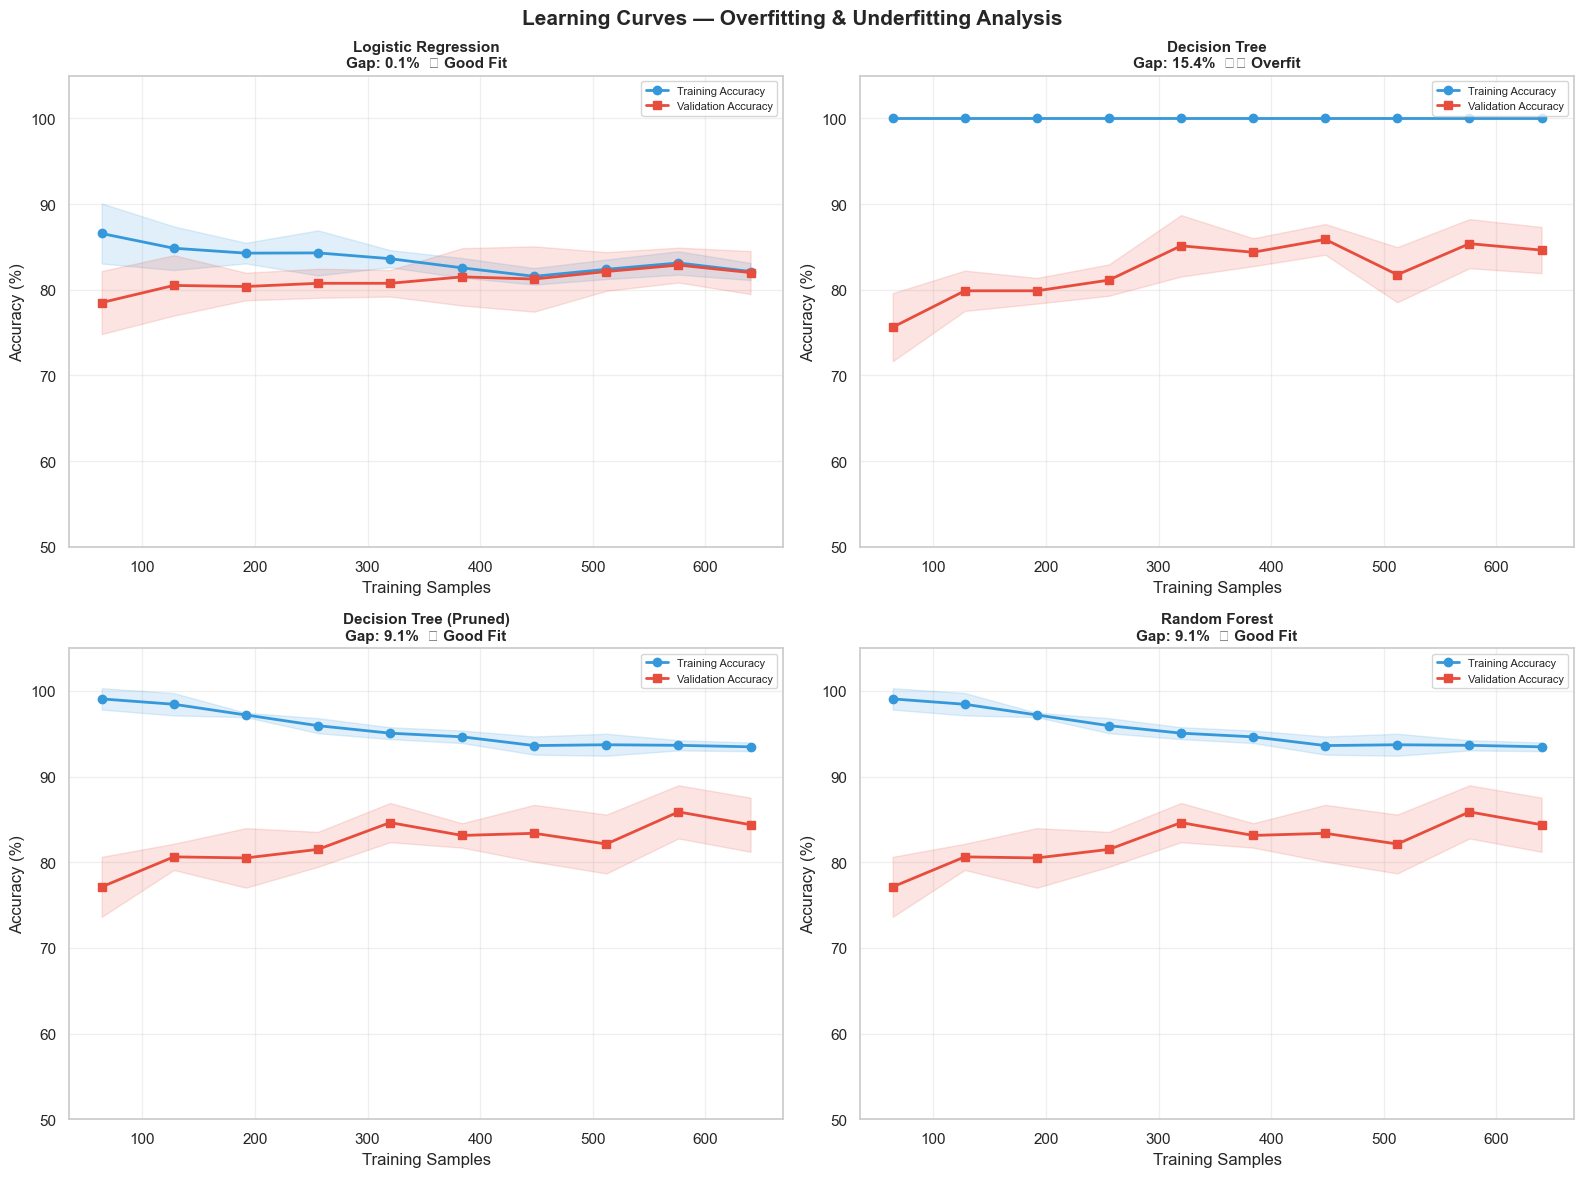


✅ Plot saved to reports/15_learning_curves.png


In [6]:
# -------------------------------------------------------
# PLOT: Learning Curves for all key models
# -------------------------------------------------------
# A learning curve shows how model performance changes
# as we give it MORE training data.
#
# HOW TO READ:
# - X-axis = number of training samples used
# - Y-axis = accuracy score
# - Blue line  = Training accuracy
# - Orange line = Validation (CV) accuracy
#
# PATTERNS:
# OVERFITTING  → Train stays high, Validation stays low (big gap)
# UNDERFITTING → Both lines are low and flat
# GOOD FIT     → Both lines converge at a high value

def plot_learning_curve(model, model_name, X, y, ax, cv=5):
    """Plot learning curve for a given model on given axes."""

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),  # 10%, 20%, ... 100%
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    # Calculate mean and std for shaded area
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Plot training score
    ax.plot(train_sizes, train_mean * 100,
            'o-', color='#3498db', linewidth=2,
            label='Training Accuracy')
    ax.fill_between(train_sizes,
                    (train_mean - train_std) * 100,
                    (train_mean + train_std) * 100,
                    alpha=0.15, color='#3498db')

    # Plot validation score
    ax.plot(train_sizes, val_mean * 100,
            's-', color='#e74c3c', linewidth=2,
            label='Validation Accuracy')
    ax.fill_between(train_sizes,
                    (val_mean - val_std) * 100,
                    (val_mean + val_std) * 100,
                    alpha=0.15, color='#e74c3c')

    # Final gap annotation
    final_gap = (train_mean[-1] - val_mean[-1]) * 100
    status = "⚠️ Overfit" if final_gap > 10 else ("⚠️ Underfit" if val_mean[-1] < 0.75 else "✅ Good Fit")

    ax.set_title(f'{model_name}\nGap: {final_gap:.1f}%  {status}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8)
    ax.set_ylim(50, 105)
    ax.grid(True, alpha=0.3)

    return train_mean[-1], val_mean[-1]

# ---- Define models to compare ----
lc_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),           # No depth limit = likely overfit
    'Decision Tree (Pruned)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'       : best_model,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

print("Generating learning curves (this may take ~1 min)...\n")
print(f"{'Model':<28} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 60)

for i, (name, model) in enumerate(lc_models.items()):
    tr, vl = plot_learning_curve(model, name, X_train, y_train, axes[i])
    status = "⚠️ Overfit" if (tr-vl)*100 > 10 else "✅ Good"
    print(f"  {name:<28} {tr*100:>8.2f}%  {vl*100:>8.2f}%  {(tr-vl)*100:>6.2f}%  {status}")

plt.suptitle('Learning Curves — Overfitting & Underfitting Analysis',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/15_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved to reports/15_learning_curves.png")

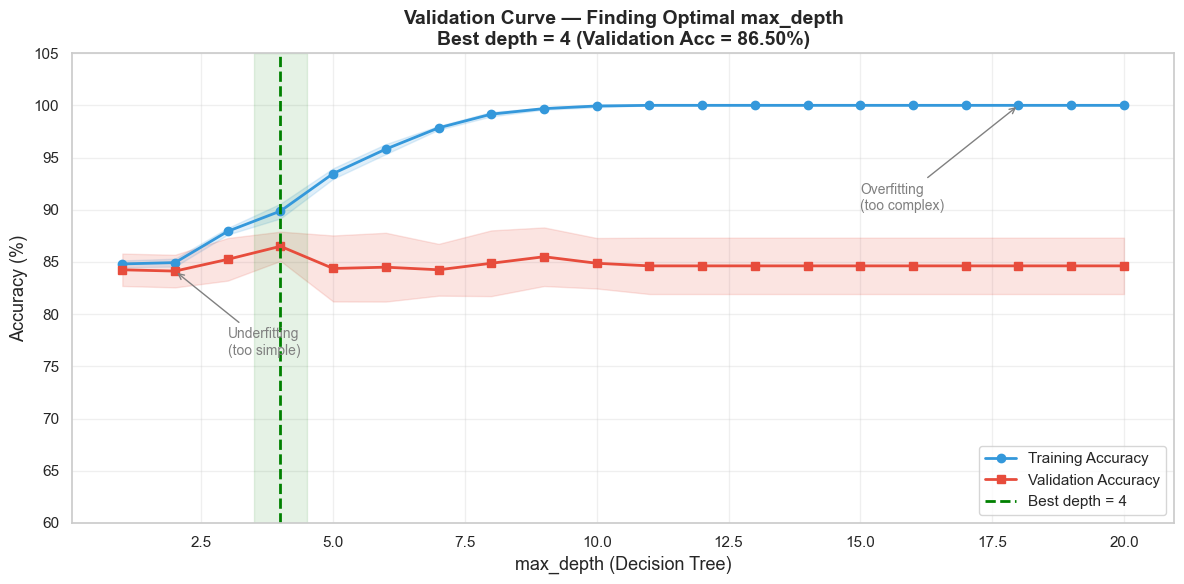

✅ Plot saved to reports/16_validation_curve.png

🎯 Best max_depth for Decision Tree: 4
   Validation Accuracy at best depth: 86.50%


In [7]:
# -------------------------------------------------------
# PLOT: Validation Curve
# -------------------------------------------------------
# A validation curve shows how ONE hyperparameter affects
# training vs validation performance.
#
# We test Decision Tree's max_depth from 1 to 20.
# This helps us find the SWEET SPOT:
# - Too shallow (low depth) → Underfitting
# - Too deep   (high depth) → Overfitting
# - Just right              → Best generalization

depths = np.arange(1, 21)  # max_depth from 1 to 20

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=depths,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1) * 100
train_std  = train_scores.std(axis=1)  * 100
val_mean   = val_scores.mean(axis=1)   * 100
val_std    = val_scores.std(axis=1)    * 100

# Find best depth
best_depth = depths[np.argmax(val_mean)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(depths, train_mean, 'o-', color='#3498db',
        linewidth=2, label='Training Accuracy')
ax.fill_between(depths, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='#3498db')

ax.plot(depths, val_mean, 's-', color='#e74c3c',
        linewidth=2, label='Validation Accuracy')
ax.fill_between(depths, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='#e74c3c')

# Mark best depth
ax.axvline(x=best_depth, color='green', linestyle='--',
           linewidth=2, label=f'Best depth = {best_depth}')
ax.axvspan(best_depth - 0.5, best_depth + 0.5,
           alpha=0.1, color='green')

# Annotate regions
ax.annotate('Underfitting\n(too simple)',
            xy=(2, val_mean[1]), xytext=(3, val_mean[1] - 8),
            fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.annotate('Overfitting\n(too complex)',
            xy=(18, train_mean[17]), xytext=(15, train_mean[17] - 10),
            fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('max_depth (Decision Tree)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title(f'Validation Curve — Finding Optimal max_depth\n'
             f'Best depth = {best_depth} (Validation Acc = {val_mean[best_depth-1]:.2f}%)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(60, 105)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/16_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to reports/16_validation_curve.png")
print(f"\n🎯 Best max_depth for Decision Tree: {best_depth}")
print(f"   Validation Accuracy at best depth: {val_mean[best_depth-1]:.2f}%")

In [8]:
# -------------------------------------------------------
# Apply fixes for overfitting on key models
# -------------------------------------------------------
# We demonstrate 3 common overfitting fixes:
# 1. Pruning (Decision Tree max_depth)
# 2. Regularization (Logistic Regression C parameter)
# 3. Tuned hyperparameters (Random Forest)

print("=" * 55)
print("   Applying Overfitting Fixes")
print("=" * 55)

fixes = {}

# --- Fix 1: Decision Tree Pruning ---
# Without pruning: tree grows until it memorizes training data
# With pruning   : we limit depth to prevent memorization
dt_overfit  = DecisionTreeClassifier(random_state=42)              # No limit
dt_pruned   = DecisionTreeClassifier(max_depth=best_depth,
                                      random_state=42)              # Pruned

dt_overfit.fit(X_train, y_train)
dt_pruned.fit(X_train, y_train)

print(f"\n1️⃣  Decision Tree Pruning:")
print(f"   Without pruning → Train: {dt_overfit.score(X_train,y_train)*100:.2f}%  "
      f"Test: {dt_overfit.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(dt_overfit.score(X_train,y_train)-dt_overfit.score(X_test,y_test))*100:.2f}%")
print(f"   With pruning    → Train: {dt_pruned.score(X_train,y_train)*100:.2f}%  "
      f"Test: {dt_pruned.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(dt_pruned.score(X_train,y_train)-dt_pruned.score(X_test,y_test))*100:.2f}%")
fixes['DT Unpruned'] = (dt_overfit.score(X_train,y_train), dt_overfit.score(X_test,y_test))
fixes['DT Pruned']   = (dt_pruned.score(X_train,y_train),  dt_pruned.score(X_test,y_test))


# --- Fix 2: Logistic Regression Regularization ---
# C = regularization strength (INVERSE: smaller C = stronger regularization)
# L2 regularization penalizes large weights → prevents overfitting
lr_no_reg = LogisticRegression(C=1000, max_iter=1000, random_state=42)  # Weak regularization
lr_reg    = LogisticRegression(C=0.1,  max_iter=1000, random_state=42)  # Strong regularization

lr_no_reg.fit(X_train, y_train)
lr_reg.fit(X_train, y_train)

print(f"\n2️⃣  Logistic Regression Regularization:")
print(f"   Weak   (C=1000) → Train: {lr_no_reg.score(X_train,y_train)*100:.2f}%  "
      f"Test: {lr_no_reg.score(X_test,y_test)*100:.2f}%")
print(f"   Strong (C=0.1)  → Train: {lr_reg.score(X_train,y_train)*100:.2f}%  "
      f"Test: {lr_reg.score(X_test,y_test)*100:.2f}%")
fixes['LR Weak Reg']   = (lr_no_reg.score(X_train,y_train), lr_no_reg.score(X_test,y_test))
fixes['LR Strong Reg'] = (lr_reg.score(X_train,y_train),    lr_reg.score(X_test,y_test))


# --- Fix 3: XGBoost with Early Stopping concept ---
# More trees = more complex = risk of overfitting
# Fewer, well-tuned trees = better generalization
xgb_complex = XGBClassifier(n_estimators=500, max_depth=8,
                              learning_rate=0.3, eval_metric='logloss',
                              random_state=42)
xgb_tuned   = XGBClassifier(n_estimators=100, max_depth=4,
                              learning_rate=0.1, eval_metric='logloss',
                              subsample=0.8,    # use 80% of data per tree
                              colsample_bytree=0.8,  # use 80% of features per tree
                              random_state=42)

xgb_complex.fit(X_train, y_train)
xgb_tuned.fit(X_train, y_train)

print(f"\n3️⃣  XGBoost Complexity Control:")
print(f"   Overcomplex → Train: {xgb_complex.score(X_train,y_train)*100:.2f}%  "
      f"Test: {xgb_complex.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(xgb_complex.score(X_train,y_train)-xgb_complex.score(X_test,y_test))*100:.2f}%")
print(f"   Tuned       → Train: {xgb_tuned.score(X_train,y_train)*100:.2f}%  "
      f"Test: {xgb_tuned.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(xgb_tuned.score(X_train,y_train)-xgb_tuned.score(X_test,y_test))*100:.2f}%")
fixes['XGB Overcomplex'] = (xgb_complex.score(X_train,y_train), xgb_complex.score(X_test,y_test))
fixes['XGB Tuned']       = (xgb_tuned.score(X_train,y_train),   xgb_tuned.score(X_test,y_test))

   Applying Overfitting Fixes

1️⃣  Decision Tree Pruning:
   Without pruning → Train: 100.00%  Test: 87.01%  Gap: 12.99%
   With pruning    → Train: 90.00%  Test: 87.66%  Gap: 2.34%

2️⃣  Logistic Regression Regularization:
   Weak   (C=1000) → Train: 82.12%  Test: 76.62%
   Strong (C=0.1)  → Train: 81.62%  Test: 77.92%

3️⃣  XGBoost Complexity Control:
   Overcomplex → Train: 100.00%  Test: 87.66%  Gap: 12.34%
   Tuned       → Train: 99.62%  Test: 88.96%  Gap: 10.66%


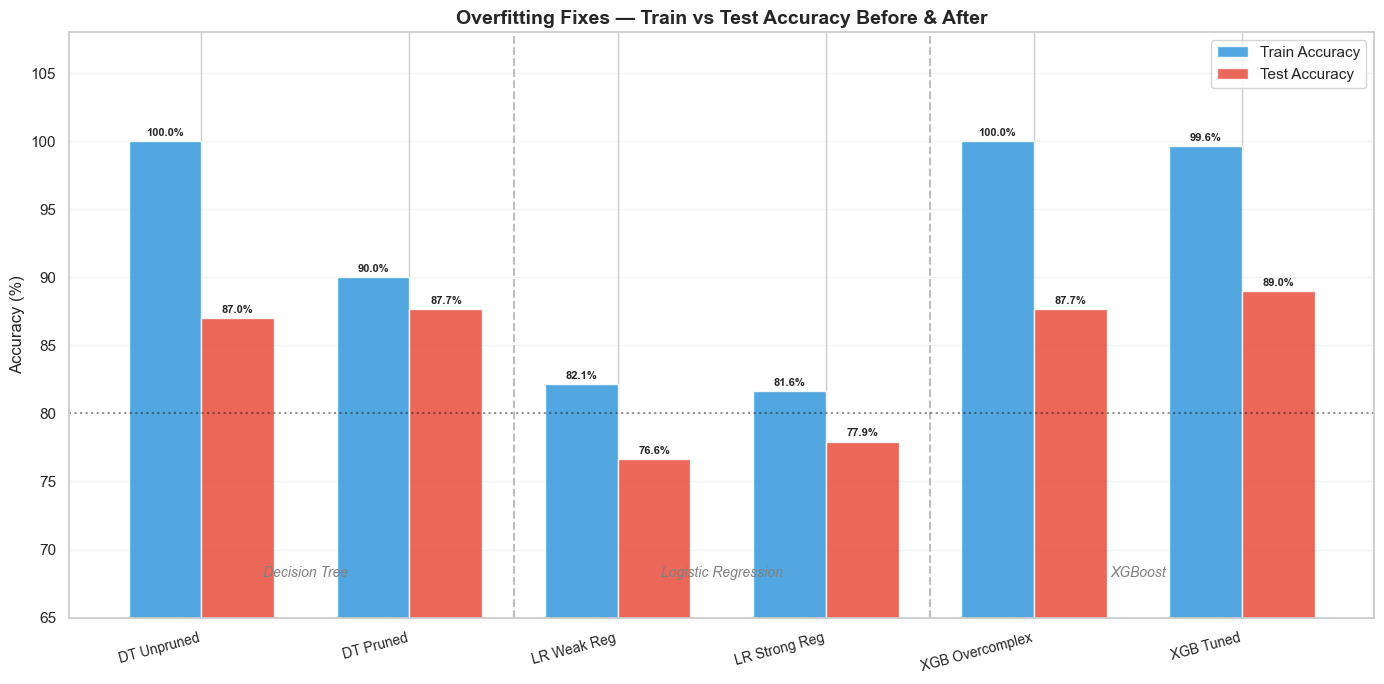

✅ Plot saved to reports/17_overfitting_fixes.png


In [9]:
# -------------------------------------------------------
# PLOT: Before vs After overfitting fixes
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 7))

models_list = list(fixes.keys())
train_accs  = [fixes[m][0] * 100 for m in models_list]
test_accs   = [fixes[m][1] * 100 for m in models_list]

x     = np.arange(len(models_list))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs, width,
               label='Train Accuracy', color='#3498db',
               edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy', color='#e74c3c',
               edgecolor='white', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# Add vertical separators between model pairs
ax.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)

# Add group labels
ax.text(0.5, 68, 'Decision Tree', ha='center', fontsize=10,
        color='gray', style='italic')
ax.text(2.5, 68, 'Logistic Regression', ha='center', fontsize=10,
        color='gray', style='italic')
ax.text(4.5, 68, 'XGBoost', ha='center', fontsize=10,
        color='gray', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(65, 108)
ax.set_title('Overfitting Fixes — Train vs Test Accuracy Before & After',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=80, color='black', linestyle=':', alpha=0.4)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../reports/17_overfitting_fixes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to reports/17_overfitting_fixes.png")

In [10]:
# -------------------------------------------------------
# Compare original best model vs tuned XGBoost
# -------------------------------------------------------
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print("=" * 60)
print("   Final Model Comparison — Original vs Tuned")
print("=" * 60)

models_final = {
    'Original Best Model' : best_model,
    'XGBoost (Tuned)'     : xgb_tuned,
    'DT (Pruned)'         : dt_pruned,
}

print(f"\n{'Model':<25} {'Accuracy':>10} {'F1':>8} {'Recall':>9} {'ROC-AUC':>9}")
print("-" * 65)

final_results = {}
for name, model in models_final.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = model.score(X_test, y_test) * 100
    f1      = f1_score(y_test, y_pred) * 100
    recall  = recall_score(y_test, y_pred) * 100
    roc_auc = roc_auc_score(y_test, y_prob) * 100

    final_results[name] = (acc, f1, recall, roc_auc)
    print(f"  {name:<25} {acc:>8.2f}%  {f1:>6.2f}%  {recall:>7.2f}%  {roc_auc:>8.2f}%")

# Select the overall best generalized model
best_final_name = max(final_results, key=lambda x: final_results[x][1])
print(f"\n🏆 Best Generalized Model: {best_final_name}")

# Save the final best model
final_best_model = models_final[best_final_name]
joblib.dump(final_best_model, '../models/final_best_model.pkl')
joblib.dump(best_final_name,  '../models/final_best_model_name.pkl')
print(f"✅ Saved to models/final_best_model.pkl")

   Final Model Comparison — Original vs Tuned

Model                       Accuracy       F1    Recall   ROC-AUC
-----------------------------------------------------------------
  Original Best Model          88.31%   84.21%    88.89%     92.66%
  XGBoost (Tuned)              88.96%   84.96%    88.89%     95.35%
  DT (Pruned)                  87.66%   84.03%    92.59%     93.97%

🏆 Best Generalized Model: XGBoost (Tuned)
✅ Saved to models/final_best_model.pkl


In [11]:
print("=" * 55)
print("      PHASE 7 — OVERFITTING ANALYSIS SUMMARY")
print("=" * 55)
print()
print("📊 Plots generated:")
print("  ✅ 15_learning_curves.png   → Diagnosed fit for 4 models")
print("  ✅ 16_validation_curve.png  → Found best max_depth")
print("  ✅ 17_overfitting_fixes.png → Before vs after fixes")
print()
print("🔧 Fixes Applied:")
print("  ✅ Decision Tree   → Pruned with optimal max_depth")
print("  ✅ Logistic Reg    → L2 regularization (C=0.1)")
print("  ✅ XGBoost         → Reduced complexity + subsampling")
print()
print("🧠 Key Concepts Demonstrated:")
print("  ✅ Learning curves  → Visual overfitting diagnosis")
print("  ✅ Validation curve → Bias-variance tradeoff")
print("  ✅ Regularization   → Penalizing model complexity")
print("  ✅ Pruning          → Limiting tree depth")
print()
print(f"🏆 Final Best Model: {best_final_name}")
print(f"   Saved to: models/final_best_model.pkl")
print()
print("➡️  Ready for Phase 8: Prediction Interface!")
print("=" * 55)

      PHASE 7 — OVERFITTING ANALYSIS SUMMARY

📊 Plots generated:
  ✅ 15_learning_curves.png   → Diagnosed fit for 4 models
  ✅ 16_validation_curve.png  → Found best max_depth
  ✅ 17_overfitting_fixes.png → Before vs after fixes

🔧 Fixes Applied:
  ✅ Decision Tree   → Pruned with optimal max_depth
  ✅ Logistic Reg    → L2 regularization (C=0.1)
  ✅ XGBoost         → Reduced complexity + subsampling

🧠 Key Concepts Demonstrated:
  ✅ Learning curves  → Visual overfitting diagnosis
  ✅ Validation curve → Bias-variance tradeoff
  ✅ Regularization   → Penalizing model complexity
  ✅ Pruning          → Limiting tree depth

🏆 Final Best Model: XGBoost (Tuned)
   Saved to: models/final_best_model.pkl

➡️  Ready for Phase 8: Prediction Interface!
